# ESM-2 bridge from SARS-CoV-2 Spike sequence to antigenic distance and immune escape
## Использование ESM-2 для построения моста от последовательности Spike к антигенной дистанции и иммунному ускользанию

## 1. Install and import dependencies

In [ ]:
!pip -q install -U "transformers>=4.38,<5" "biopython>=1.81"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.1 MB/s eta 0:00:00


In [ ]:
import re, random, shutil, warnings, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from Bio import SeqIO
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics.pairwise import cosine_distances
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

## 2. Runtime and reproducibility

In [ ]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available(): print("GPU:", torch.cuda.get_device_name(0))
import transformers, sklearn, scipy
print(f"PyTorch {torch.__version__}; Transformers {transformers.__version__}; sklearn {sklearn.__version__}; SciPy {scipy.__version__}")

Device: cuda
GPU: Tesla T4
PyTorch 2.11.0+cu128; Transformers 4.57.6; sklearn 1.6.1; SciPy 1.16.3


In [ ]:
from pathlib import Path

variants = [
    "Wuhan", "Alpha", "Beta", "Gamma", "Delta",
    "BA.1", "BA.2", "BA.5", "XBB", "JN.1"
]

output_path = Path("/content/spike_variants.fasta")

with output_path.open("w") as output:
    for variant in variants:
        file_path = Path(f"/content/{variant}.fasta")

        if not file_path.exists():
            raise FileNotFoundError(f"Missing file: {file_path.name}")

        sequence_lines = []
        seen_header = False

        for line in file_path.read_text().splitlines():
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if seen_header:
                    break
                seen_header = True
            elif seen_header:
                sequence_lines.append(line)

        sequence = "".join(sequence_lines)
        if not sequence:
            raise ValueError(f"No FASTA sequence found in {file_path.name}")

        output.write(f">{variant}\n")
        output.write(sequence + "\n")

print(f"Created: {output_path}")
print("Included variants:", ", ".join(variants))

Created: /content/spike_variants.fasta
Included variants: Wuhan, Alpha, Beta, Gamma, Delta, BA.1, BA.2, BA.5, XBB, JN.1


## 3. Dataset: curated FASTA first, transparent demo fallback

In [ ]:
AUTO_UPLOAD = False
if AUTO_UPLOAD:
    try:
        from google.colab import files
        files.upload()
    except ImportError:
        print("Interactive upload is available in Google Colab only.")

EXPECTED_VARIANTS = ["Wuhan","Alpha","Beta","Gamma","Delta","BA.1","BA.2","BA.5","XBB","JN.1"]
metadata = pd.DataFrame([
 ("Wuhan","Reference","Baseline",0.0,"Reference; score fixed to zero."),
 ("Alpha","Pre-Omicron","Low",1.0,"Broad literature-informed category."),
 ("Beta","Pre-Omicron","Low to moderate",2.0,"E484K and assay-dependent escape context."),
 ("Gamma","Pre-Omicron","Low to moderate",2.0,"Broad, assay-dependent category."),
 ("Delta","Pre-Omicron","Medium",3.0,"Moderate category."),
 ("BA.1","Omicron","High",4.0,"Early Omicron with marked antigenic change."),
 ("BA.2","Omicron","High",4.0,"Broad Omicron category."),
 ("BA.5","Omicron","Very high",5.0,"Substantial escape in many studies."),
 ("XBB","Recombinant Omicron","Very high / maximum",6.0,"Highly immune-evasive qualitative category."),
 ("JN.1","Descendant Omicron","Very high / maximum",6.0,"Highly immune-evasive qualitative category."),
], columns=["variant","group","expected_escape_category","literature_escape_numeric","notes"])
ALIASES = {"wuhan":"Wuhan","reference":"Wuhan","wild-type":"Wuhan","alpha":"Alpha","beta":"Beta","gamma":"Gamma","delta":"Delta","ba.1":"BA.1","ba1":"BA.1","ba.2":"BA.2","ba2":"BA.2","ba.5":"BA.5","ba5":"BA.5","xbb":"XBB","jn.1":"JN.1","jn1":"JN.1"}
AA = set("ACDEFGHIKLMNPQRSTVWY")

def canonical_name(header):
    text = header.lower().replace("_", " ")
    for key in sorted(ALIASES, key=len, reverse=True):
        if key in text: return ALIASES[key]
    return None

def make_demo_sequences():
    """Synthetic (not biological) 1273-aa inputs for pipeline demonstration only."""
    base = ("ACDEFGHIKLMNPQRSTVWY" * 64)[:1273]
    n_changes = dict(zip(EXPECTED_VARIANTS, [0,4,8,9,14,28,31,38,50,55]))
    alphabet = "ACDEFGHIKLMNPQRSTVWY"; output = {}
    for rank, name in enumerate(EXPECTED_VARIANTS):
        chars = list(base)
        for j in range(n_changes[name]):
            pos = (23*j + 37*rank + 11) % len(chars)
            chars[pos] = alphabet[(alphabet.index(chars[pos]) + rank + 3) % len(alphabet)]
        output[name] = "".join(chars)
    return output

def load_spike_sequences(fasta_path="/content/spike_variants.fasta"):
    """Load recognized real sequences from FASTA or use transparent demo fallback."""
    candidates = [Path(fasta_path), Path("spike_variants.fasta")]
    found = next((p for p in candidates if p.exists()), None)
    if found is None:
        print("WARNING: Real FASTA sequences were not found. The notebook is running in DEMO mode. For final scientific results, upload curated real Spike sequences.")
        return make_demo_sequences(), "DEMO"
    output = {}
    for record in SeqIO.parse(str(found), "fasta"):
        name = canonical_name(record.description)
        if name: output[name] = str(record.seq)
        else: print("Ignoring unrecognized header:", record.description)
    print(f"Loaded {len(output)} recognized sequences from {found.resolve()}")
    return output, "REAL_FASTA"

sequences_raw, data_mode = load_spike_sequences()
print("Data mode:", data_mode)
display(metadata)

Loaded 10 recognized sequences from /content/spike_variants.fasta
Data mode: REAL_FASTA


,variant,group,expected_escape_category,literature_escape_numeric,notes
0,Wuhan,Reference,Baseline,0.0,Reference; score fixed to zero.
1,Alpha,Pre-Omicron,Low,1.0,Broad literature-informed category.
2,Beta,Pre-Omicron,Low to moderate,2.0,E484K and assay-dependent escape context.
3,Gamma,Pre-Omicron,Low to moderate,2.0,"Broad, assay-dependent category."
4,Delta,Pre-Omicron,Medium,3.0,Moderate category.
5,BA.1,Omicron,High,4.0,Early Omicron with marked antigenic change.
6,BA.2,Omicron,High,4.0,Broad Omicron category.
7,BA.5,Omicron,Very high,5.0,Substantial escape in many studies.
8,XBB,Recombinant Omicron,Very high / maximum,6.0,Highly immune-evasive qualitative category.
9,JN.1,Descendant Omicron,Very high / maximum,6.0,Highly immune-evasive qualitative category.


## 4. Sequence cleaning and quality control

In [ ]:
AA = set("ACDEFGHIKLMNPQRSTVWYXBZOU")

In [ ]:
def clean_sequence(sequence):
    return re.sub(r"\s+", "", str(sequence).upper()).replace("-", "").replace("*", "")

def validate_sequences(raw, expected=EXPECTED_VARIANTS, min_length=900):
    cleaned, rows = {}, []
    for name, value in raw.items():
        seq = clean_sequence(value); invalid = sorted(set(seq) - AA)
        rows.append({"variant":name,"length_aa":len(seq),"invalid_characters":"".join(invalid) or "None","suspiciously_short":len(seq)<min_length,"status":"valid" if not invalid else "invalid"})
        if not invalid: cleaned[name] = seq
    qc = pd.DataFrame(rows).sort_values("variant")
    display(qc)
    missing = [x for x in expected if x not in cleaned]
    if missing:
        raise ValueError("Required variants missing or invalid: " + ", ".join(missing) + ". Check headers/letters. Expected: " + ", ".join(expected))
    short = qc.loc[qc.suspiciously_short, "variant"].tolist()
    if short: print("WARNING: suspiciously short sequences:", ", ".join(short))
    return {x:cleaned[x] for x in expected}, qc

sequences, sequence_qc = validate_sequences(sequences_raw)

,variant,length_aa,invalid_characters,suspiciously_short,status
1,Alpha,1270,None,False,valid
5,BA.1,1273,None,False,valid
6,BA.2,1270,None,False,valid
7,BA.5,1268,None,False,valid
2,Beta,1270,None,False,valid
4,Delta,1271,None,False,valid
3,Gamma,1273,None,False,valid
9,JN.1,1273,None,False,valid
0,Wuhan,1273,None,False,valid
8,XBB,1269,None,False,valid


## 5. Load ESM-2

In [ ]:
MODEL_NAME = "facebook/esm2_t12_35M_UR50D"
print("Loading", MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()
print("Hidden size:", model.config.hidden_size, "| tokenizer max length:", tokenizer.model_max_length)

Loading facebook/esm2_t12_35M_UR50D


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/136M [00:00<?, ?B/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Hidden size: 480 | tokenizer max length: 1000000000000000019884624838656


## 6. Long Spike sequences: overlap-aware embedding

In [ ]:
def chunk_sequence(sequence, max_len=900, overlap=100):
    if max_len <= 0 or overlap < 0 or overlap >= max_len: raise ValueError("Require max_len > 0 and 0 <= overlap < max_len.")
    if len(sequence) <= max_len: return [sequence]
    return [sequence[i:i+max_len] for i in range(0, len(sequence), max_len-overlap) if sequence[i:i+max_len]]

@torch.no_grad()
def embed_protein_sequence(sequence, tokenizer, model, device, max_len=900, overlap=100):
    """One 480-D sequence vector from overlap-aware ESM-2 residue pooling."""
    vectors, weights = [], []
    for chunk in chunk_sequence(clean_sequence(sequence), max_len, overlap):
        batch = tokenizer(chunk, return_tensors="pt", add_special_tokens=True, truncation=True)
        batch = {k:v.to(device) for k,v in batch.items()}
        hidden = model(**batch).last_hidden_state[0]
        residues = hidden[1:1+len(chunk)]  # drop beginning/end special tokens
        if len(residues) != len(chunk): raise RuntimeError("Unexpected tokenization length; inspect input sequence.")
        vectors.append(residues.mean(0).cpu().numpy()); weights.append(len(chunk))
    return np.average(np.vstack(vectors), axis=0, weights=weights)

def embed_all_variants(sequences):
    names, vectors = [], []
    for name, seq in tqdm(sequences.items(), desc="Embedding Spike variants"):
        names.append(name); vectors.append(embed_protein_sequence(seq, tokenizer, model, device))
    matrix = np.vstack(vectors)
    df = pd.DataFrame(matrix, index=names, columns=[f"esm2_{i:03d}" for i in range(matrix.shape[1])]); df.index.name = "variant"
    return matrix, df, names

embeddings, embedding_df, variant_order = embed_all_variants(sequences)
assert embeddings.shape == (10, 480), f"Unexpected embedding shape: {embeddings.shape}"
print("Embedding matrix shape:", embeddings.shape)
display(embedding_df.iloc[:,:8].round(4))

Embedding Spike variants:   0%|          | 0/10 [00:00<?, ?it/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Embedding matrix shape: (10, 480)


,esm2_000,esm2_001,esm2_002,esm2_003,esm2_004,esm2_005,esm2_006,esm2_007
variant,,,,,,,,
Wuhan,0.0001,0.0452,-0.0096,0.0654,-0.0221,-0.0238,-0.0179,-0.0912
Alpha,0.0009,0.0423,-0.0076,0.0656,-0.0215,-0.0254,-0.0166,-0.0896
Beta,-0.0030,0.0405,-0.0061,0.0651,-0.0209,-0.0284,-0.0156,-0.0897
Gamma,-0.0026,0.0434,-0.0039,0.0648,-0.0127,-0.0280,-0.0127,-0.0814
Delta,-0.0049,0.0457,-0.0103,0.0622,-0.0240,-0.0227,-0.0229,-0.0907
BA.1,-0.2967,-0.1469,-0.1962,0.0477,-0.2385,-0.2295,-0.1936,-0.1140
BA.2,0.0035,0.0445,0.0024,0.0553,-0.0237,-0.0287,-0.0323,-0.0898
BA.5,-0.0228,0.0123,-0.0071,0.0624,-0.0479,-0.0554,-0.0490,-0.0863
XBB,0.0033,0.0417,0.0046,0.0516,-0.0213,-0.0266,-0.0334,-0.0907


## 7. Antigenic distance matrix

In [ ]:
distance_array = cosine_distances(embeddings); np.fill_diagonal(distance_array, 0)
distance_df = pd.DataFrame(distance_array, index=variant_order, columns=variant_order); distance_df.index.name = "variant"
distance_df.to_csv("antigenic_distance_matrix.csv")
display(distance_df.round(4)); print("Saved: antigenic_distance_matrix.csv")

,Wuhan,Alpha,Beta,Gamma,Delta,BA.1,BA.2,BA.5,XBB,JN.1
variant,,,,,,,,,,
Wuhan,0.0000,0.0001,0.0001,0.0001,0.0001,0.5213,0.0004,0.0041,0.0004,0.0008
Alpha,0.0001,0.0000,0.0001,0.0002,0.0001,0.5219,0.0003,0.0039,0.0004,0.0007
Beta,0.0001,0.0001,0.0000,0.0001,0.0001,0.5222,0.0003,0.0040,0.0004,0.0007
Gamma,0.0001,0.0002,0.0001,0.0000,0.0002,0.5224,0.0005,0.0042,0.0005,0.0006
Delta,0.0001,0.0001,0.0001,0.0002,0.0000,0.5209,0.0003,0.0040,0.0004,0.0007
BA.1,0.5213,0.5219,0.5222,0.5224,0.5209,0.0000,0.5199,0.4538,0.5214,0.5205
BA.2,0.0004,0.0003,0.0003,0.0005,0.0003,0.5199,0.0000,0.0038,0.0001,0.0006
BA.5,0.0041,0.0039,0.0040,0.0042,0.0040,0.4538,0.0038,0.0000,0.0039,0.0040
XBB,0.0004,0.0004,0.0004,0.0005,0.0004,0.5214,0.0001,0.0039,0.0000,0.0004


Saved: antigenic_distance_matrix.csv


## 8. Immune Escape Score

In [ ]:
def score_category(s):
    if s <= .20: return "Low"
    if s <= .45: return "Medium"
    if s <= .75: return "High"
    return "Very high / maximum"

d0 = distance_df.loc["Wuhan", variant_order]
nonref = d0.drop("Wuhan"); denom = nonref.max() - nonref.min()
if np.isclose(denom, 0):
    print("WARNING: equal non-reference distances; setting scores to zero."); normalized = pd.Series(0., index=variant_order)
else:
    normalized = ((d0 - nonref.min()) / denom).clip(0,1)
normalized.loc["Wuhan"] = 0.
scores_df = metadata.merge(pd.DataFrame({"variant":variant_order,"distance_from_wuhan":d0.values,"immune_escape_score":normalized.values}), on="variant", how="right")
scores_df["model_interpretation"] = scores_df.immune_escape_score.map(score_category)
scores_df.to_csv("immune_escape_scores.csv", index=False)
display(scores_df[["variant","group","distance_from_wuhan","immune_escape_score","expected_escape_category","model_interpretation"]].round(4))
print("Saved: immune_escape_scores.csv")

,variant,group,distance_from_wuhan,immune_escape_score,expected_escape_category,model_interpretation
0,Wuhan,Reference,0.0000,0.0000,Baseline,Low
1,Alpha,Pre-Omicron,0.0001,0.0000,Low,Low
2,Beta,Pre-Omicron,0.0001,0.0000,Low to moderate,Low
3,Gamma,Pre-Omicron,0.0001,0.0001,Low to moderate,Low
4,Delta,Pre-Omicron,0.0001,0.0000,Medium,Low
5,BA.1,Omicron,0.5213,1.0000,High,Very high / maximum
6,BA.2,Omicron,0.0004,0.0006,High,Low
7,BA.5,Omicron,0.0041,0.0077,Very high,Low
8,XBB,Recombinant Omicron,0.0004,0.0007,Very high / maximum,Low
9,JN.1,Descendant Omicron,0.0008,0.0014,Very high / maximum,Low


Saved: immune_escape_scores.csv


## 9. Presentation visualizations

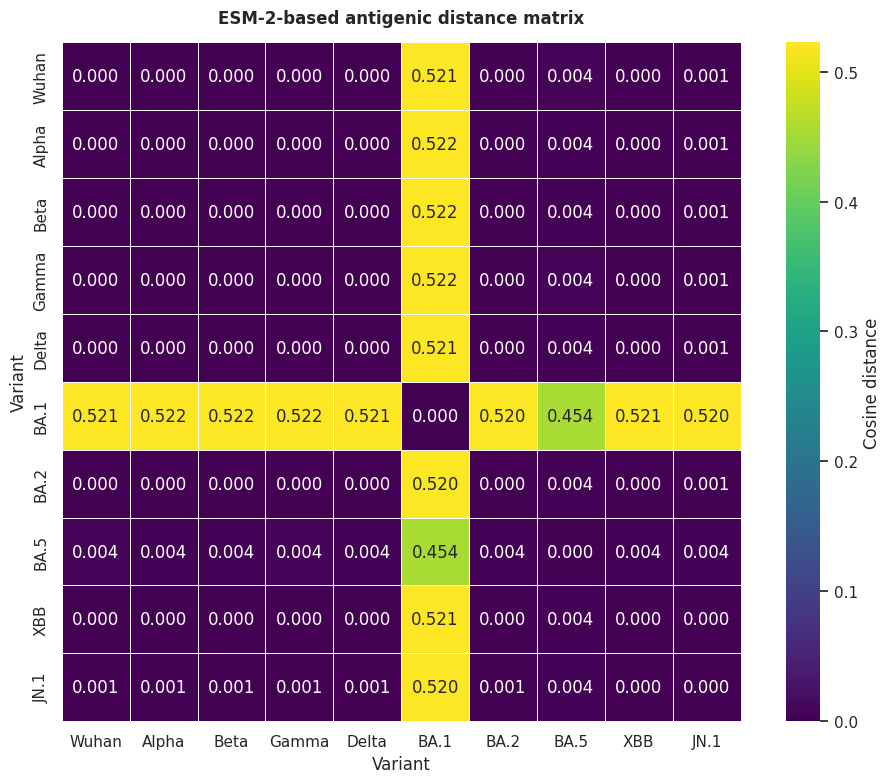

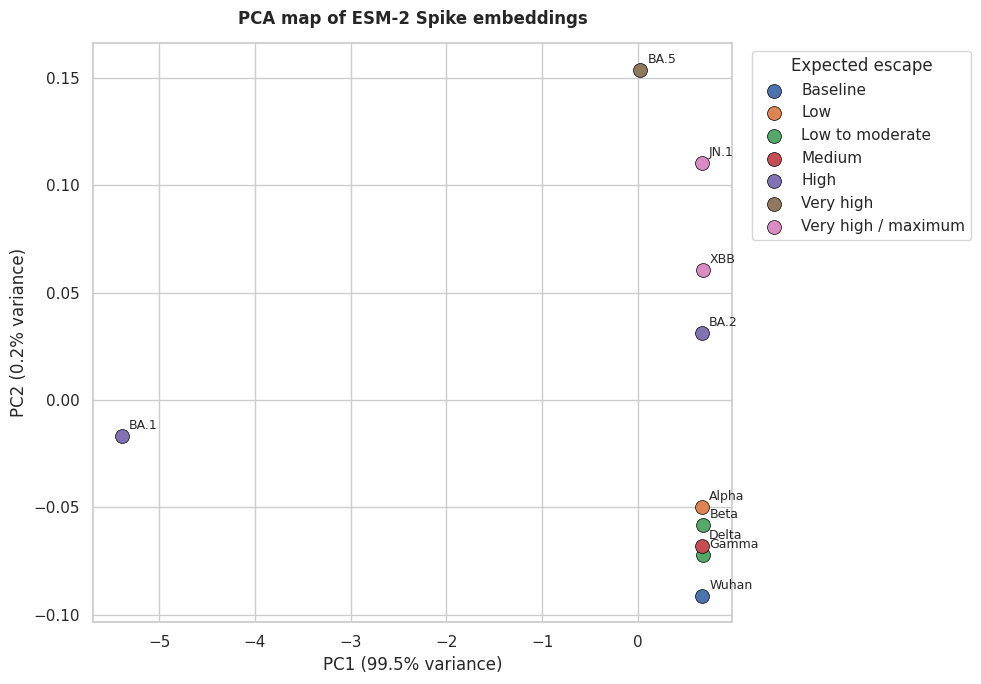

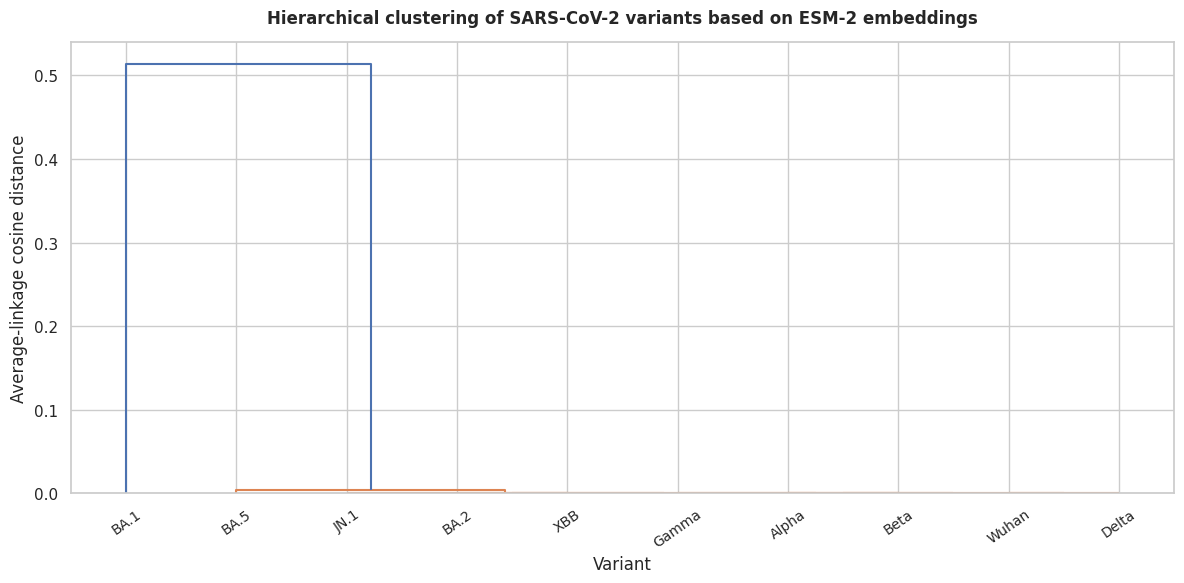

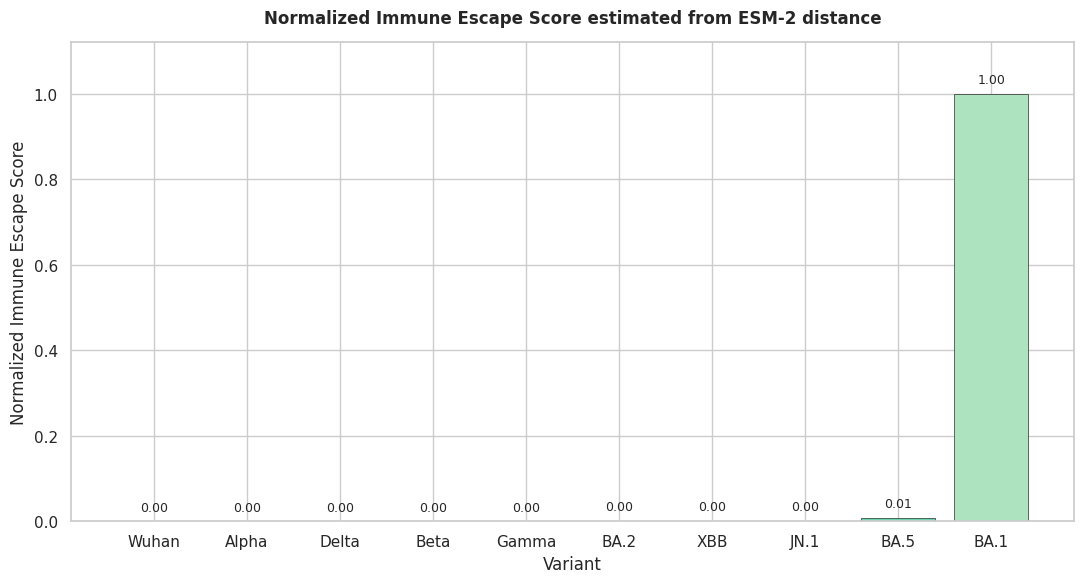

In [ ]:
FIG_DPI = 220
plt.figure(figsize=(10,8)); sns.heatmap(distance_df, cmap="viridis", annot=True, fmt=".3f", square=True, linewidths=.4, cbar_kws={"label":"Cosine distance"})
plt.title("ESM-2-based antigenic distance matrix", weight="bold", pad=14); plt.xlabel("Variant"); plt.ylabel("Variant"); plt.tight_layout(); plt.savefig("figure_1_antigenic_distance_heatmap.png", dpi=FIG_DPI, bbox_inches="tight"); plt.show()

pca = PCA(n_components=2, random_state=SEED); xy = pca.fit_transform(embeddings)
pca_df = pd.DataFrame({"variant":variant_order,"PC1":xy[:,0],"PC2":xy[:,1]}).merge(metadata[["variant","expected_escape_category"]],on="variant")
plt.figure(figsize=(10,7))
for category, part in pca_df.groupby("expected_escape_category", sort=False):
    plt.scatter(part.PC1,part.PC2,s=100,label=category,edgecolor="black",linewidth=.5)
    for _, r in part.iterrows(): plt.annotate(r.variant,(r.PC1,r.PC2),xytext=(5,5),textcoords="offset points",fontsize=9)
plt.title("PCA map of ESM-2 Spike embeddings",weight="bold",pad=14); plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)"); plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(title="Expected escape",bbox_to_anchor=(1.02,1),loc="upper left"); plt.tight_layout(); plt.savefig("figure_2_pca_embedding_map.png",dpi=FIG_DPI,bbox_inches="tight"); plt.show()

Z = linkage(squareform(distance_array, checks=False), method="average")
plt.figure(figsize=(12,6)); dendrogram(Z,labels=variant_order,leaf_rotation=35,leaf_font_size=10)
plt.title("Hierarchical clustering of SARS-CoV-2 variants based on ESM-2 embeddings",weight="bold",pad=14); plt.xlabel("Variant"); plt.ylabel("Average-linkage cosine distance"); plt.tight_layout(); plt.savefig("figure_3_variant_clustering_dendrogram.png",dpi=FIG_DPI,bbox_inches="tight"); plt.show()

plot_scores = scores_df.sort_values("immune_escape_score")
plt.figure(figsize=(11,6)); bars=plt.bar(plot_scores.variant,plot_scores.immune_escape_score,color=sns.color_palette("mako",len(plot_scores)),edgecolor="black",linewidth=.4)
plt.ylim(0,1.12); plt.title("Normalized Immune Escape Score estimated from ESM-2 distance",weight="bold",pad=14); plt.xlabel("Variant"); plt.ylabel("Normalized Immune Escape Score")
for b,v in zip(bars,plot_scores.immune_escape_score): plt.text(b.get_x()+b.get_width()/2,v+.025,f"{v:.2f}",ha="center",fontsize=9)
plt.tight_layout(); plt.savefig("figure_4_immune_escape_score.png",dpi=FIG_DPI,bbox_inches="tight"); plt.show()

## 10. Validation with literature-informed categories

,variant,expected_escape_category,literature_escape_numeric,distance_from_wuhan,immune_escape_score,model_interpretation,match_or_close_match
0,Wuhan,Baseline,0.0,0.0000,0.0000,Low,exact match
1,Alpha,Low,1.0,0.0001,0.0000,Low,exact match
2,Beta,Low to moderate,2.0,0.0001,0.0000,Low,close match
3,Gamma,Low to moderate,2.0,0.0001,0.0001,Low,close match
4,Delta,Medium,3.0,0.0001,0.0000,Low,close match
5,BA.1,High,4.0,0.5213,1.0000,Very high / maximum,close match
6,BA.2,High,4.0,0.0004,0.0006,Low,mismatch
7,BA.5,Very high,5.0,0.0041,0.0077,Low,mismatch
8,XBB,Very high / maximum,6.0,0.0004,0.0007,Low,mismatch
9,JN.1,Very high / maximum,6.0,0.0008,0.0014,Low,mismatch


Pearson r=0.073, p=0.8528
Spearman rho=0.760, p=0.0176


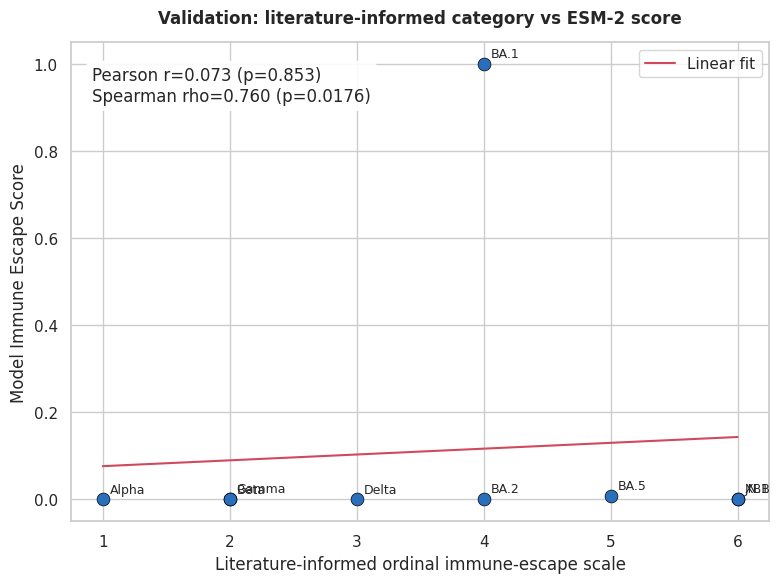

In [ ]:
def expected_level(x):
    x=x.lower()
    return 3 if "very high" in x else 2 if x=="high" else 1 if ("medium" in x or "moderate" in x) else 0
def model_level(x):
    return 3 if "very high" in x.lower() else 2 if x=="High" else 1 if x=="Medium" else 0
def match_label(row):
    d=abs(expected_level(row.expected_escape_category)-model_level(row.model_interpretation))
    return "exact match" if d==0 else "close match" if d==1 else "mismatch"

validation_df=scores_df.copy(); validation_df["match_or_close_match"]=validation_df.apply(match_label,axis=1)
v=validation_df.query("variant != 'Wuhan'")
pearson_r,pearson_p=pearsonr(v.literature_escape_numeric,v.immune_escape_score); spearman_r,spearman_p=spearmanr(v.literature_escape_numeric,v.immune_escape_score)
display(validation_df[["variant","expected_escape_category","literature_escape_numeric","distance_from_wuhan","immune_escape_score","model_interpretation","match_or_close_match"]].round(4))
print(f"Pearson r={pearson_r:.3f}, p={pearson_p:.4f}"); print(f"Spearman rho={spearman_r:.3f}, p={spearman_p:.4f}")
if data_mode=="DEMO": print("DEMO MODE NOTICE: statistics only confirm that the pipeline executed; they are not scientific validation.")

plt.figure(figsize=(8,6)); X=v.literature_escape_numeric.to_numpy().reshape(-1,1); y=v.immune_escape_score.to_numpy()
plt.scatter(X.ravel(),y,s=85,color="#2a6fbb",edgecolor="black",linewidth=.5); fit=LinearRegression().fit(X,y); xx=np.linspace(X.min(),X.max(),100).reshape(-1,1); plt.plot(xx,fit.predict(xx),color="#d1495b",label="Linear fit")
for _,r in v.iterrows(): plt.annotate(r.variant,(r.literature_escape_numeric,r.immune_escape_score),xytext=(5,5),textcoords="offset points",fontsize=9)
plt.title("Validation: literature-informed category vs ESM-2 score",weight="bold",pad=14); plt.xlabel("Literature-informed ordinal immune-escape scale"); plt.ylabel("Model Immune Escape Score")
plt.text(.03,.95,f"Pearson r={pearson_r:.3f} (p={pearson_p:.3g})\nSpearman rho={spearman_r:.3f} (p={spearman_p:.3g})",transform=plt.gca().transAxes,va="top",bbox=dict(boxstyle="round",facecolor="white",alpha=.9)); plt.legend(); plt.tight_layout(); plt.savefig("figure_5_validation_correlation.png",dpi=FIG_DPI,bbox_inches="tight"); plt.show()

## 11. Optional epidemiological bridge

In [ ]:
epidemiology_bridge=scores_df[["variant","immune_escape_score"]].copy()
epidemiology_bridge["estimated_cross_immunity"]=1-epidemiology_bridge.immune_escape_score
display(epidemiology_bridge.round(4))

,variant,immune_escape_score,estimated_cross_immunity
0,Wuhan,0.0000,1.0000
1,Alpha,0.0000,1.0000
2,Beta,0.0000,1.0000
3,Gamma,0.0001,0.9999
4,Delta,0.0000,1.0000
5,BA.1,1.0000,0.0000
6,BA.2,0.0006,0.9994
7,BA.5,0.0077,0.9923
8,XBB,0.0007,0.9993
9,JN.1,0.0014,0.9986
